# MDTF Great Plains low-level jet diagnostic tool. 

================================================================================

This notebook performances diagnostic tests to assess a model's ability to capture the physics of the Great Plains low-level jet. 


## Version & Contact info
* In-progress version (7/16/26)
* PI: Stephen Leroy (JANUS/AER, stephen.leroy [at] janusresearch.us)
* Developer: Sara Vannah (JANUS/AER, sara.vannah [at] janusresearch.us)
* Other contributors: Yi Ming (Boston College), Pu Lin (Boston College)


## Open source copyright agreement
The MDTF framework is distributed under the LGPLv3 license (see LICENSE.txt). Unless you've distributed your script elsewhere, you don't need to change this.

## Functionality

The code produces three diagnostics comparing the specified model to data over a specified region and specified time range. The regions used are also plotted in the diagnostic section for reference. Everything you should need to change within the code are in the top cell.  

These comparisons are:


### Frequency, height, and jet speed
* **Maps of probability, height, and speed of LLJ.**
       <p>The probablity of occurrence is determined using the Bonner criterion-1, which defines a low-level jet as a wind pattern that must reach a max speed of 12 ms$^{-1}$ at some height in the PBL, but returns 6 ms$^{-1}$ between the geopotential height of the max windspeed and 3 km[1]. The probability of occurence is given as the percentage of reanalysis datapoints during the specificied time period that have an LLJ even by this criterion. We note that this is different from a probability of daily occurence: while the LLJ is primarily a diurnal phenomenon, one 24 hour segment may contain multiple discreet LLJs. For example, an LLJ that is breaking down in the early hours of the day and an LLJ that is beginning to form in the late hours of the day would be counted as two LLJs in a single day, even though this pattern would only mean a single LLJ forming each night.</p>

   <p>The LLJ height is given as the mean of the the geopotential height of the LLJ max speed over the specified time range. Similarly, the LLJ speed is the mean of the maximum LLJ speed over the specified time period. </p>
   
### Column water vapor flux
* **Maps of water vapor flux vectors.**
    <p> Column water vapor mass flux, $\mathbf{F}_{\mathrm{wv}}$, is computed according to
    $$\mathbf{F}_{\mathrm{wv}} = \biggl[ {1 \over g_0} \sum_{j=1}^{i-1} q_j \mathbf{u}_j \bigl( p_{j-\frac{1}{2}} - p_{j+\frac{1}{2}} \bigr) \biggr] + 
{ q_i \mathbf{u}_i \over g_0 } \bigl( p_{i-\frac{1}{2}} - p(h={3\ \mathrm{km}}) \bigr) $$
for $\mathbf{u}_j$ the horizontal wind vector of layer $j$, layer $i-1$ is the topmost layer beneath 3 km above the surface, and $p(h={3\ \mathrm{km}})$ the pressure evaluated at exactly 3 km above the surface.
   </p>
   
* **Plot of mean water vapor flux by month and time of day.**
    Column water calpor flux is computed as above, but only over a specified linear segment (e.g. the Gulf Coast), plotted in purple in the maps figure.


### Vertical-diurnal structure

* **Plot of wind speed vectors at varying heights, separated by month and time of day. **
    <p> 3-hourly wind-speed for each month is interpolated onto a horizontal grid on isohypses with ???? m increments in geopotential height. The wind speeds at each height for each timestep are then averaged over the bounding box specified in the maps figure. The result is a series of plots of wind vectors (showing their speed and direction) over the diurnal cycle. </p>

*   **Comparison of wind speed vectors to rawinsonde data. **
    <p> This is the same as above, but 6-hourly data is compared to rawinsonde data from the Southern Great Plains DOE site. The interpolation is sum-sampled to ???? m. </p> 


## Required programming language and libraries
This program uses the standard MDTF conda environment with the additional installation of the pyllj package from https://github.com/ssleroy/pyllj .

* Python >= 3.12
* xrarray
* matplotlib
* intake
* yaml
* sys
* os
* numpy
* pyllj is required as it contains many of the LLJ utilities used in this POD. 
* scipy is required by pyllj
* datetime is required by pyllj
* netCDF4 is required by pyllj 
* tqdm is required by pyllj 
* cartopy is required for plotting by pyllj
* earthaccess (a NASA Earthdata package) is required by pyllj
* cdaspi (a package for interfacing with the Climate Data Store) is required by pyllj

## Required model output variables

In this section you should describe each variable in the input data your diagnostic uses. You also need to provide this in the settings.jsonc file, but here you should go into detail on the assumptions your diagnostic makes about the structure of the data.

* tas - Surface (2-m) air temperature (CF: air_temperature)

## References

[1] BONNER, W. D., 1968: CLIMATOLOGY OF THE LOW LEVEL JET. Mon. Wea. Rev., 96, 833–850, https://doi.org/10.1175/1520-0493(1968)096<0833:COTLLJ>2.0.CO;2.

## TODO:
* add paper references 
* water vapor flux... reword? 
* get interp height for both wind vector plots 
* does earthaccess (NASA Earthdata python package) auto-install scipy, datetime, cartopy? Not sure if these need to be separate dependencies
* determine required model output variables


%Developed from the [esnb framework](https://github.com/jkrasting/esnb)

More details on the development process:
[MDTF Planning Document](https://docs.google.com/document/d/1P8HqL8O5304qwR3ik9RmgFDwSWwlkPgOjnp39PIkLfY/edit?usp=sharing)

In [1]:
# Development mode: constantly refreshes module code
%load_ext autoreload
%autoreload 2

    
# General imports.
import esnb
from esnb import NotebookDiagnostic, RequestedVariable, CaseGroup2
from esnb.sites.gfdl import call_dmget
from netCDF4 import Dataset
import numpy as np
import pyllj
from datetime import datetime, timezone, timedelta
import os
import matplotlib.pyplot as plt
import shutil

# Framework Code and Diagnostic Setup

Uncomment and run the cell below the first time you run the notebook to set up the data cache. 

In [2]:




##################################################
#             User-set parameters. 
##################################################
# Everything you should need to modify is contained
# within this this cell. 
##################################################

set_cache = False # Set to true the first time notebook is run to cache data.
region = "Great Plains" # currently only hosted region, option to add more
data_root = "~/pyllj-data"

'UWIS0041'

In [3]:
# Start-up and default parameters. 
############################################

if set_cache:
    configure_cache(data_root)
    
os.environ["DATAROOT"] = data_root
months = "Jan Feb Mar Apr May Jun Jul Aug Sep Oct Nov Dec".split()

# Imports from pyllj package. 
from pyllj.podutilities.diagnostics import plot_summer_llj_diagnostics
from pyllj.podutilities.libpod import configure_cache
from pyllj.podutilities.watervaporflux import plot_watervaporflux
from pyllj.podutilities.boundaryflux import plot_boundaryflux
from pyllj.podutilities.isohypses import WindBarbs, compute_windbarbs, windbarbs_ax
from pyllj.podutilities.libpod import get_metricpath
from pyllj.parameters import default_dataroot, plot_regions

DATAROOT = ~/pyllj-data


In [4]:
axeslinewidth = 0.5
plt.rcParams.update( {
    'font.family': 'serif', 
    'font.size': 9, 
    'font.weight': "normal", 
    'text.usetex': False, 
    'xtick.major.width': axeslinewidth, 
    'xtick.minor.width': axeslinewidth, 
    'ytick.major.width': axeslinewidth, 
    'ytick.minor.width': axeslinewidth, 
    'axes.linewidth': axeslinewidth } )
plt.rcParams["mathtext.fontset"] = "stix"

plt.rcParams.update({'text.usetex': False})

# Diagnostics
The 

Saving to regions.pdf


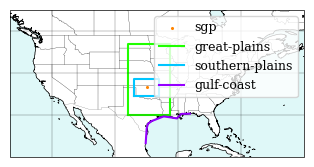

In [5]:
plot_regions( legend=True )

Reading /home/vannahs/pyllj-data/narr_diagnostics.nc
Generating narr plots
Reading /home/vannahs/pyllj-data/merra2_diagnostics.nc
Generating merra2 plots
Reading /home/vannahs/pyllj-data/era5_diagnostics.nc
Generating era5 plots
Creating summer_llj_diagnostics.pdf


RetClass
  success=True
  messages=
  comments=

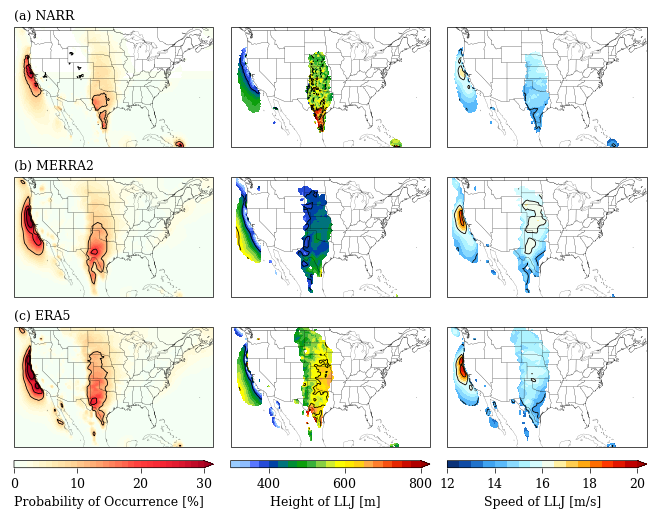

In [6]:
plot_summer_llj_diagnostics(outputfile="summer_llj_diagnostics.pdf")

## Prepare POD settings. 

In [5]:
# Options are "prod" or "interactive."
# For "prod", POD options will be read from JSON. 
# For "interactive", user will need to add all POD options by hand.
mode = "prod"

verbose = True

# Give your diagnostic a name and a short description
diag_name = "Great Plains low-level jet diagnostic"
diag_desc = "This example demonstrates how to use the notebook template"

In [ ]:
if (mode == "interactive"):
  settings_dict = {
    "settings": {

        # ---------------------------------------------------
        # The pod_env_vars are used in the POD, not required by the MDTF framework
        # ---------------------------------------------------
        "pod_options": {
            # Options of running processes. Set "False" if this process has been completed before.
            "plot_summer_llj_diagnostics": "True",
            "plot_watervaporflux": "True",
            "plot_boundaryflux": "True",
            "plot_regions": "True",
            "plot_windbarbs_full": "True",
            "plot_windbarbs_summer": "True",

            ## The time range of the MCS analysis. The MCS identification will generate files at
            ## each timestep within this specified range, so consider 1-2 years to reduce computation time and save storage space
            #"start_time": "20050101.0600",
            #"end_time": "20060101.0000",
            ## The latitude range:
            #"latitude_max": 30,
            #"latitude_min": -30,
            ## The regridded resolution from the native resolution
            ## precipitation statistics, buoyancy 2-D histograms (0.25, 0.5, or 1 degree)
            "regrid_res": 1,
            # The number of workers used for parallel computation. Recommended for high-resolution models (<= 0.5 degree)
            # Default is 8, which can be run on a general personal laptop.
            "num_workers": 8
        },

        # ---------------------------------------------------
        # The following settings are used by the MDTF framework
        # ---------------------------------------------------
        "runtime_requirements": {
            "python3": None,  # None means use the default python version of the MDTF framework
        },
        "driver": "mdtf_llj_pod.ipynb",
        "long_name": "Great Plains low-level jet diagnostic",
        "convention": "cmip",
        "description": "Great Plains low-level jet diagnostic",
    },
    "dimensions": {
        "lat": {
                "standard_name": "latitude",
                "units": "degrees_north",
                "axis": "Y"
            },
        "lon": {
                "standard_name": "longitude",
                "units": "degrees_east",
                "axis": "X"
            },
        "plev": {
                "standard_name": "air_pressure",
                "units": "hPa",
                "positive": "down",
                "axis": "Z"
            },
        "time": {"standard_name": "time"}
    },

    # In this section, user can describe what model data the diagnostic uses. Add one
    # list entry (the section in curly braces) for each variable, separated by commas.
    "varlist" : {
        # Variable identifier. A variable with this name will be set to
        # what the corresponding field is called in the model being analyzed.
        "pr": {
                "standard_name" : "precipitation_flux",
                "requirement": "required",
                "realm": "atmos",
                "units": "kg m-2 s-1",
                "frequency" : "6hr",
                "dimensions": ["time", "lat", "lon"]
        },
        "rlut": {
                "standard_name" : "toa_outgoing_longwave_flux",
                "requirement": "required",
                "realm": "atmos",
                "units": "W m-2",
                "frequency" : "6hr",
                "dimensions": ["time", "lat", "lon"]
        },
        "ta": {
                "standard_name": "air_temperature",
                "requirement": "required",
                "realm": "atmos",
                "units": "K",
                "frequency" : "6hr",
                "dimensions" : ["time", "plev", "lat", "lon"]
            },
        "hus": {
                "standard_name": "specific_humidity",
                "requirement": "required",
                "realm": "atmos",
                "frequency" : "6hr",
                "units": "kg/kg",
                "dimensions" : ["time", "plev", "lat", "lon"]
            }
    },
    }
# batch mode: running mdtf executable from the command line, read settings from the settings.jsonc file
else:
    # Specify the path to the JSONC file
    settings_file_path = os.path.join(module_path, "diagnostics/MCS_precip_buoy_stats/settings.jsonc")

    try:
        # Open and read the JSONC file using MDTF framework's json_utils
        settings_dict = json_utils.read_json(settings_file_path)
    except Exception as e:
        print(f"An unexpected error occurred when reading the JSONC file: {e}")

# Pretty-print the loaded JSON data
# print(json_utils.pretty_print_json(settings_dict))

In [ ]:
if (mode == "interactive"):
    # If running in interactive mode, input case settings are made here. Otherwise they are read from the input settings file,
    # which should contain everything. Extra key value pairs can be added in a later cell.
    case_info = {
     "case_list": {
            "MPI-ESM1-2-HR_historical_r1i1p1f1_gn": # this is the case/model name
            {
                "convention": "CMIP",
                "enddate": "20060101000000",
                "model": "MPI-ESM1-2-HR",
                "startdate": "20050101060000",
                'frequency': '6hr'
            }
        },
        #"DATA_CATALOG": "/scratch/leih/mdtf/catalogs/MPI-ESM1-2-HR_historical_r11i1p1f1.esnb.json",
        #"OBS_DATA_ROOT": "/scratch/leih/mdtf/inputdata/obs_data",
        #"WORK_DIR": "/scratch/leih/mdtf/wkdir",
        #"OUTPUT_DIR": "/scratch/leih/mdtf/wkdir", #leaving blank will use the WORK_DIR
        "conda_env_root": "/home/vannahs/miniconda3/envs",
        "conda_root": "/home/vannahs/miniconda3/envs",
        "large_file": False,
        "make_multicase_figure_html": False,
        "make_variab_tar": False,
        "micromamba_exe": "",
        "overwrite": True,
        "pod_list": ["MCS_precip_buoy_stats"],
        "run_pp": True,
        "save_pp_data": True,
        "save_ps": False,
        "translate_data": True,
        "user_pp_scripts": [""]
    }
else:
    # Receive a dictionary of case information from the framework.
    # This needs to be passed from the MDTF framework (will be an argument to the command line call)"
    case_input_file =  os.path.join(module_path, "runtime_config.MCS.yml")
    print("reading default settings from {case_input_file}")

    assert os.path.isfile(case_input_file), f"case environment file not found"
    with open(case_input_file, 'r') as stream:
        try:
            case_info = yaml.safe_load(stream)
        except yaml.YAMLError as exc:
            print(exc)

# Load metadata and catalog files. 

Reading /home/vannahs/pyllj-data/narr_diagnostics.nc
Generating narr plots
Reading /home/vannahs/pyllj-data/merra2_diagnostics.nc
Generating merra2 plots
Reading /home/vannahs/pyllj-data/era5_diagnostics.nc
Generating era5 plots
Creating summer_llj_diagnostics.pdf


RetClass
  success=True
  messages=
  comments=

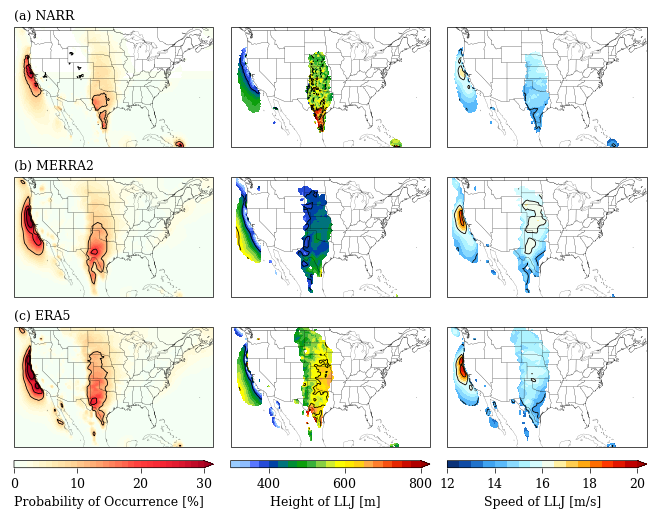

Saving to watervaporflux.pbl.pdf.


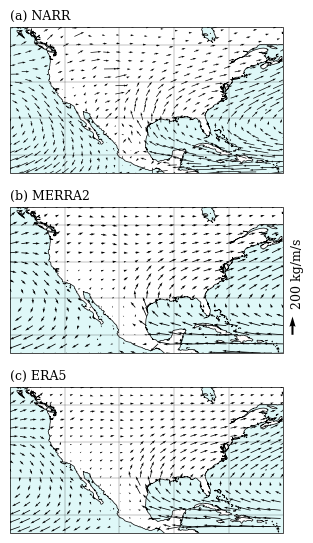

In [7]:
#plot_summer_llj_diagnostics( outputfile="diagnostics.pdf" )
plot_watervaporflux( layer="pbl", nx=1, outputfile="watervaporflux.pbl.pdf" )
#plot_boundaryflux( layer="pbl", outputfile="boundaryflux.pbl.pdf" )
#plot_regions( legend=True )
#plot_windbarbs_full( region="southern-plains" )
#plot_windbarbs_summer( region="southern-plains", 
#                          outputfile="windbarbs_summer.southern-plains.pdf", 
#                          scale_length=5.0 ) 
#plot_windbarbs_summer( reference="narr", region="southern-plains", 
#                          outputfile="windbarbs_summer_narr_reference.southern-plains.pdf", 
#                          scale=2.5, scale_length=1.0 ) 
#plot_windbarbs_summer_sgp( outputfile="windbarbs_summer_sgp.pdf" ) 


Reading /home/vannahs/pyllj-data/narr_boundaryflux.great-plains.nc
Reading /home/vannahs/pyllj-data/merra2_boundaryflux.great-plains.nc
Reading /home/vannahs/pyllj-data/era5_boundaryflux.great-plains.nc
Units are Gtons per hour
Saving to boundaryflux.pbl.pdf


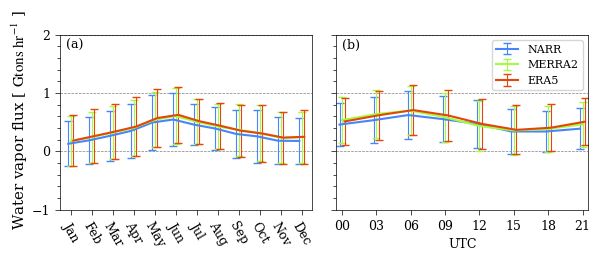

In [8]:
plot_boundaryflux( layer="pbl", outputfile="boundaryflux.pbl.pdf" )

Saving to regions.pdf


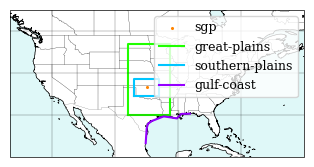

In [10]:
def plot_windbarbs_full( reanalysis:{"narr","merra2","era5"}="narr", region="southern-plains", 
        scale=12.0, scale_length=10.0, outputfile=None ): 

    #  Get data. 

    w = compute_windbarbs( reanalysis, region=region )
    windbarbs = WindBarbs( **w )

    #  Define output file. 

    if outputfile is None: 
        outfile = f'{reanalysis}_windbarbs.{region}.pdf'
    else: 
        outfile = outputfile

    #  Geometry of figure. 

    xmargin = 0.45
    ymargin = 0.40
    nx, ny = 4, 3

    figsize = ( xmargin + 1.5 * nx, ymargin + 1.2 * ny )
    offset = np.array( [ xmargin/figsize[0], ymargin/figsize[1], 0.0, 0.0 ] )
    window = np.array( [ 0.04, 0.04, 0.90, 0.80 ] )
    wscale = ( 1.0 - np.array( [ offset[0], offset[1], offset[0], offset[1] ] ) ) / np.array( [nx,ny,nx,ny] )

    fig = plt.figure( figsize=figsize )

    xmin, xmax = 0.5, 0.5
    ymin, ymax = 0.5, 0.5

    #  Loop over month. 

    for imonth in range(12): 

        ix, iy = imonth % nx, ny - int(imonth/nx) - 1
        pos = ( window + np.array( [ix,iy,0,0] ) ) * wscale + offset

        xmin, xmax = min( xmin, pos[0] ), max( xmax, pos[0]+pos[2] )
        ymin, ymax = min( ymin, pos[1] ), max( ymax, pos[1]+pos[3] )

        meta = { 'xticks': (iy==0), 'yticks': (ix==0), 'scale': scale, 'scale_length': None }
        if ix==nx-1 and iy==0: 
            meta['scale_length'] = scale_length

        ax = windbarbs_ax( fig, pos, windbarbs, imonths=imonth, **meta )
        ax.set_xlabel( "" )
        ax.set_ylabel( "" )

        label = '({:}) {:}'.format( chr(ord('a')+imonth), months[imonth] )
        ax.text( -2.0, 3.12, label, ha="left" )

    fig.supxlabel( "UTC hour", x=0.5*(xmin+xmax), y=0.01, ha="center", va="bottom" )
    fig.supylabel( "Height above surface [km]", x=0.01, y=0.5*(ymin+ymax), ha="left", va="center" )

    print( f'Saving to {outfile}' )
    fig.savefig( outfile )

    return


def plot_windbarbs_summer( reference=None, region="southern-plains", 
        outputfile="windbarbs_summer.pdf", scale=12.0, scale_length=10.0 ): 

    #  Get data. 

    windbarbs = []
    for reanalysis in [ "narr", "merra2", "era5" ]: 
        w = compute_windbarbs( reanalysis, region=region )
        windbarbs.append( WindBarbs( **w ) )

    #  Geometry of figure. 

    xmargin = 0.35
    ymargin = 0.35

    if reference is None: 
        nx, ny = len(windbarbs), 1
    else: 
        nx, ny = len(windbarbs)-1, 1

    figsize = ( xmargin + 1.9 * nx, ymargin + 1.5 * ny )
    offset = np.array( [ xmargin/figsize[0], ymargin/figsize[1], 0.0, 0.0 ] )
    window = np.array( [ 0.04, 0.04, 0.90, 0.80 ] )
    wscale = ( 1.0 - np.array( [ offset[0], offset[1], offset[0], offset[1] ] ) ) / np.array( [nx,ny,nx,ny] )

    fig = plt.figure( figsize=figsize )

    xmin, xmax = 0.5, 0.5
    ymin, ymax = 0.5, 0.5

    #  Loop over month. 

    isummer = np.arange(5,8)
    ix, iy = -1, 0

    if reference is not None: 
        wbref = [ wb for wb in windbarbs if wb.model==reference ]
        if len( wbref ) != 1: 
            print( f'Model {reference} does not exist and cannot be used as a reference. Exiting.' )
            return
        wbref = wbref[0]

    for wb in windbarbs: 

        if reference is None: 
            ix += 1
            wbp = wb
        else: 
            if wb.model == wbref.model: 
                continue
            else: 
                ix += 1
                wbp = wb - wbref
        pos = ( window + np.array( [ix,iy,0,0] ) ) * wscale + offset

        xmin, xmax = min( xmin, pos[0] ), max( xmax, pos[0]+pos[2] )
        ymin, ymax = min( ymin, pos[1] ), max( ymax, pos[1]+pos[3] )

        meta = { 'xticks': (iy==0), 'yticks': (ix==0), 'scale_length': None, 'scale': scale }
        if ix==nx-1 and iy==0: 
            meta['scale_length'] = scale_length

        ax = windbarbs_ax( fig, pos, wbp, imonths=isummer, **meta )
        ax.set_xlabel( "" )
        ax.set_ylabel( "" )

        label = '({:}) {:}'.format( chr(ord('a')+ix), wbp.modelname )
        ax.text( -2.0, 3.12, label, ha="left" )

    fig.supxlabel( "UTC hour", x=0.5*(xmin+xmax), y=0.01, ha="center", va="bottom" )
    fig.supylabel( "Height above surface [km]", x=0.01, y=0.5*(ymin+ymax), ha="left", va="center" )

    print( f'Saving to {outputfile}' )
    fig.savefig( outputfile )

    return


def plot_windbarbs_summer_sgp( outputfile="windbarbs_summer_sgp.pdf" ): 

    scale, scale_length = 2.5, 1.0

    #  Get data. 

    reanalyses_at_sgp = []
    reanalyses_at_southernplains = []

    for reanalysis in [ "narr", "merra2", "era5" ]: 
        analysisfile = os.path.join( default_dataroot, reanalysis.upper(), "isohypses", "isohypses.2007-2020.nc" )
        w = compute_windbarbs( analysisfile, sourcelabel=reanalysis.upper(), sonde="sgp" )
        reanalyses_at_sgp.append( WindBarbs( **w ) )
        w = compute_windbarbs( analysisfile, sourcelabel=reanalysis.upper(), region="southern-plains" )
        reanalyses_at_southernplains.append( WindBarbs( **w ) )

    #  Use SGP climatology as reference for all plots. 

    w = compute_windbarbs( "sgp" )
    sgp = WindBarbs( **w )

    #  Geometry of figure. 

    xmargin = 0.35
    ymargin = 0.35
    nx, ny = 3, 2

    figsize = ( xmargin + 1.9 * nx, ymargin + 1.5 * ny )
    offset = np.array( [ xmargin/figsize[0], ymargin/figsize[1], 0.0, 0.0 ] )
    window = np.array( [ 0.04, 0.04, 0.90, 0.80 ] )
    wscale = ( 1.0 - np.array( [ offset[0], offset[1], offset[0], offset[1] ] ) ) / np.array( [nx,ny,nx,ny] )

    fig = plt.figure( figsize=figsize )

    xmin, xmax = 0.5, 0.5
    ymin, ymax = 0.5, 0.5

    #  Loop over month. 

    isummer = np.arange(5,8)
    ix, iy = -1, 0
    iplot = 0

    for reanalyses, clabel in [ ( reanalyses_at_sgp, "SGP" ), ( reanalyses_at_southernplains, "Southern Plains" ) ]: 
        for wb in reanalyses: 
            wbp = wb - sgp
            ix, iy = iplot % nx, ny - int(iplot/nx) - 1
            pos = ( window + np.array( [ix,iy,0,0] ) ) * wscale + offset

            xmin, xmax = min( xmin, pos[0] ), max( xmax, pos[0]+pos[2] )
            ymin, ymax = min( ymin, pos[1] ), max( ymax, pos[1]+pos[3] )

            meta = { 'xticks': (iy==0), 'yticks': (ix==0), 'scale_length': None, 'scale': scale }
            if ix==nx-1 and iy==0: 
                meta['scale_length'] = scale_length

            ax = windbarbs_ax( fig, pos, wbp, imonths=isummer, **meta )
            ax.set_xlabel( "" )
            ax.set_ylabel( "" )

            label = '({:}) {:}({:})'.format( chr(ord('a')+iplot), wb.sourcename, clabel )
            ax.text( -2.0, 3.12, label, ha="left" )

            iplot += 1

    fig.supxlabel( "UTC hour", x=0.5*(xmin+xmax), y=0.01, ha="center", va="bottom" )
    fig.supylabel( "Height above surface [km]", x=0.01, y=0.5*(ymin+ymax), ha="left", va="center" )

    print( f'Saving to {outputfile}' )
    fig.savefig( outputfile )

    return


Reading coordinate metadata from /home/vannahs/pyllj-data/narr_isohypses.nc
Lambert = True, nx = 349, ny=277, nmonths=12, nlevels=30, nhours=8
Projection:
  false_easting: 5632642.22547
  false_northing: 4612545.65137
  grid_mapping_name: lambert_conformal_conic
  latitude_of_projection_origin: 50.0
  longitude_of_central_meridian: -107.0
  standard_parallel: [50. 50.]
LLJ bounding box:
  lonrange = 259.5, 265.5
  latrange = 34.6, 38.6
Saving to narr_windbarbs.southern-plains.pdf


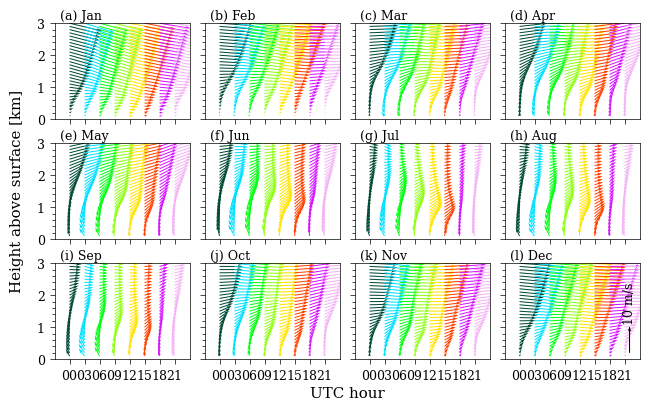

In [11]:
plot_windbarbs_full( region="southern-plains" )

Reading coordinate metadata from /home/vannahs/pyllj-data/narr_isohypses.nc
Lambert = True, nx = 349, ny=277, nmonths=12, nlevels=30, nhours=8
Projection:
  false_easting: 5632642.22547
  false_northing: 4612545.65137
  grid_mapping_name: lambert_conformal_conic
  latitude_of_projection_origin: 50.0
  longitude_of_central_meridian: -107.0
  standard_parallel: [50. 50.]
LLJ bounding box:
  lonrange = 259.5, 265.5
  latrange = 34.6, 38.6
Reading coordinate metadata from /home/vannahs/pyllj-data/merra2_isohypses.nc
Lambert = False, nx = 121, ny=81, nmonths=12, nlevels=30, nhours=8
LLJ bounding box:
  lonrange = 259.5, 265.5
  latrange = 34.6, 38.6
Reading coordinate metadata from /home/vannahs/pyllj-data/era5_isohypses.nc
Lambert = False, nx = 301, ny=161, nmonths=12, nlevels=30, nhours=8
LLJ bounding box:
  lonrange = 259.5, 265.5
  latrange = 34.6, 38.6
Saving to windbarbs_summer.southern-plains.pdf


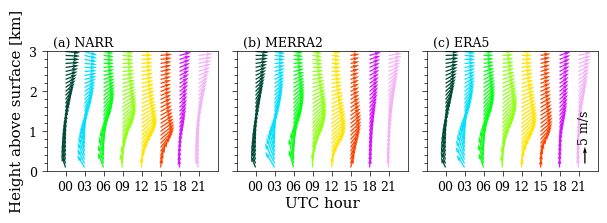

In [12]:
plot_windbarbs_summer( region="southern-plains", 
                          outputfile="windbarbs_summer.southern-plains.pdf", 
                          scale_length=5.0 ) 

Reading coordinate metadata from /home/vannahs/pyllj-data/narr_isohypses.nc
Lambert = True, nx = 349, ny=277, nmonths=12, nlevels=30, nhours=8
Projection:
  false_easting: 5632642.22547
  false_northing: 4612545.65137
  grid_mapping_name: lambert_conformal_conic
  latitude_of_projection_origin: 50.0
  longitude_of_central_meridian: -107.0
  standard_parallel: [50. 50.]
LLJ bounding box:
  lonrange = 259.5, 265.5
  latrange = 34.6, 38.6
Reading coordinate metadata from /home/vannahs/pyllj-data/merra2_isohypses.nc
Lambert = False, nx = 121, ny=81, nmonths=12, nlevels=30, nhours=8
LLJ bounding box:
  lonrange = 259.5, 265.5
  latrange = 34.6, 38.6
Reading coordinate metadata from /home/vannahs/pyllj-data/era5_isohypses.nc
Lambert = False, nx = 301, ny=161, nmonths=12, nlevels=30, nhours=8
LLJ bounding box:
  lonrange = 259.5, 265.5
  latrange = 34.6, 38.6
Saving to windbarbs_summer_narr_reference.southern-plains.pdf


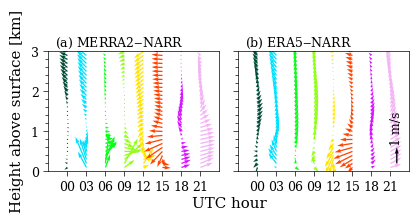

In [13]:
plot_windbarbs_summer( reference="narr", region="southern-plains", 
                          outputfile="windbarbs_summer_narr_reference.southern-plains.pdf", 
                          scale=2.5, scale_length=1.0 ) 

In [4]:
%%time

# Define a mode (leave "prod" for now)
mode = "prod"

# Verbosity
verbose = True

# Give your diagnostic a name and a short description
diag_name = "Example Notebook-based Diagnostic"
diag_desc = "This example demonstrates how to use the notebook template"

# Define what variables you would like to analyze. The first entry is the
# variable name and the second entry is the realm (post-processing dir).
#   (By default, monthly timeseries data will be loaded. TODO: add documentation
#    on how to select different frequencies, multiple realms to search, etc.)
variables = [
    RequestedVariable("zos", "ocean_month"),
    RequestedVariable("tos", "ocean_month"),
    RequestedVariable("tas", "atmos_cmip"),
]

# Optional: define runtime settings or options for your diagnostic
user_options = {"enso_region": ["nino34"]}

# Initialize the diagnostic with its name, description, vars, and options
diag = NotebookDiagnostic(diag_name, diag_desc, variables=variables, **user_options)

# Define the groups of experiments to analyze. Provide a single dora id for one experiment
# or a list of IDs to aggregate multiple experiments into one; e.g. historical+future runs
groups = [
    CaseGroup2("cm5-9", date_range=("0041-01-01", "0060-12-31")),
    CaseGroup2(
        [1188, 1243],
        "time",
        name="ESM4 Historical + Future",
        date_range=("1993-01-01", "2022-12-31"),
    ),
]

# Combine the experiments with the diag request and determine what files need to be loaded:
diag.resolve(groups)

2026-07-01 10:30:59,993 - CRITICAL - gfdl.py:369 - Network route to dora is unavailble. Check connection.
CPU times: user 80.7 ms, sys: 34.7 ms, total: 115 ms
Wall time: 3min 11s


ConnectTimeout: HTTPSConnectionPool(host='dora.gfdl.noaa.gov', port=443): Max retries exceeded with url: /api/intake/catalog/cm5-9.csv.gz (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x1554c73dd4c0>, 'Connection to dora.gfdl.noaa.gov timed out. (connect timeout=None)'))

In [ ]:
# Print a list of file paths
# This cell and the markdown cell that follows are necessary to run this notebook
# Interactively on Dora
_ = [print(x) for x in diag.files]

<i>(The files above are necessary to run the diagnostic.)</i>

In [ ]:
# Check to see the dmget status before calling "open"
call_dmget(diag.files,status=True)

In [ ]:
# Load the data as xarray datasets
diag.open()

In [ ]:
diag.variables[0]

## Exploring Datasets by Looping Over Variables

In [ ]:
# First loop over variables, and then over groups

for variable in diag.variables:
    for group in variable.datasets.keys():
        ds = variable.datasets[group]
        print("\n")
        print(f"Variable={variable}, Group={group}")
        print(ds)

## Exploring Datasets by Looping over Groups

In [ ]:
# First loop over groups, and then over variables

for group in diag.groups:
    for variable in group.datasets.keys():
        ds = group.datasets[variable]
        print("\n")
        print(f"Variable={variable}, Group={group}")
        print(ds)